# 08: Exploratory Data Analysis - Feature Relationships

**Goal**: Understand feature associations, correlations, and relationships to identify:
1. How features relate to transit accessibility
2. Connections between well-connected and poorly connected areas
3. Key factors for improving LA Metro and bus system in highest demand areas

**What We'll Explore**:
- Feature distributions and summary statistics
- Correlation matrices (all features vs accessibility)
- Scatter plots: features vs accessibility
- Well-connected vs poorly connected area comparisons
- Spatial patterns in feature relationships
- Interaction effects between features

**Key Questions**:
- What demographic/geographic factors are associated with high accessibility?
- How do well-connected areas differ from transit deserts?
- Are there patterns that suggest where to prioritize transit improvements?
- Do spatial lags reveal neighborhood effects?


In [1]:
from pathlib import Path
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

try:
    from libpysal.weights import Queen
    SPATIAL_AVAILABLE = True
except ImportError:
    SPATIAL_AVAILABLE = False
    print("⚠ libpysal not available. Spatial lag features will be skipped.")

ROOT = Path("/Users/aaryakhanna/transit-deserts").resolve()
os.chdir(ROOT)

data_raw = ROOT / "data_raw"
outputs = ROOT / "outputs"

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ Imports loaded")
print(f"Working directory: {ROOT}")


✓ Imports loaded
Working directory: /Users/aaryakhanna/transit-deserts


## Step 1: Load Data and Create Features


In [2]:
print("Loading data from previous notebooks...")

tracts = gpd.read_file(outputs / "tracts_with_accessibility.geojson")
tracts['GEOID'] = tracts['GEOID'].astype(str)

tracts['median_income'] = tracts['median_income'].replace(-666666666, np.nan)

# Use 30-minute accessibility as target variable
target_col = 'access_30min_per1k'

tracts[target_col] = tracts[target_col].replace([np.inf, -np.inf], np.nan)

tracts_eda = tracts[
    tracts[target_col].notna() & 
    tracts['pop_total'].notna() & 
    (tracts['pop_total'] > 0) &
    tracts['median_income'].notna()
].copy()

print(f"✓ Loaded {len(tracts_eda):,} tracts with valid data")
print(f"  Target variable: {target_col}")
print(f"  Mean accessibility: {tracts_eda[target_col].mean():.1f} jobs/1k")
print(f"  Median accessibility: {tracts_eda[target_col].median():.1f} jobs/1k")


Loading data from previous notebooks...
✓ Loaded 975 tracts with valid data
  Target variable: access_30min_per1k
  Mean accessibility: 168349.2 jobs/1k
  Median accessibility: 98881.5 jobs/1k


In [3]:
print("\nCreating features for analysis...")

# Project to UTM for distance calculations
tracts_proj = tracts_eda.to_crs('EPSG:32611')

features = pd.DataFrame(index=tracts_proj.index)
features['income'] = tracts_proj['median_income']
features['pop_total'] = tracts_proj['pop_total']
features['jobs_total'] = tracts_proj['jobs_total']
features['pop_density'] = tracts_proj['pop_total'] / (tracts_proj.geometry.area / 1e6)  # per km²
features['jobs_density'] = tracts_proj['jobs_total'] / (tracts_proj.geometry.area / 1e6)  # per km²

features['income_x_pop'] = features['income'] * features['pop_total'] / 1e6
features['income_x_jobs'] = features['income'] * features['jobs_total'] / 1e6
features['pop_x_jobs'] = features['pop_total'] * features['jobs_total'] / 1e9

# Spatial features: neighbor averages (spatial lag)
if SPATIAL_AVAILABLE:
    print("  Creating spatial lag features...")
    try:
        w_queen = Queen.from_dataframe(tracts_proj, use_index=False)
        w_queen.transform = 'r'
        
        # Calculate spatial lags (weighted averages of neighbors)
        for col in ['income', 'pop_total', 'jobs_total', 'pop_density', 'jobs_density']:
            if col in features.columns:
                lag_values = []
                for idx in features.index:
                    try:
                        neighbors = w_queen.neighbors[idx]
                        if neighbors:
                            neighbor_values = [features.loc[n, col] for n in neighbors if n in features.index]
                            lag_values.append(np.mean(neighbor_values) if neighbor_values else np.nan)
                        else:
                            lag_values.append(np.nan)
                    except (KeyError, IndexError):
                        lag_values.append(np.nan)
                features[f'{col}_lag'] = lag_values
        
        print(f"  ✓ Created spatial lag features for {len([c for c in features.columns if '_lag' in c])} variables")
    except Exception as e:
        print(f"  ⚠ Error creating spatial lags: {e}")
else:
    print("  ⚠ Skipping spatial lag features (libpysal not available)")

# Geographic features (centroid coordinates)
centroids = tracts_proj.geometry.centroid
features['x_coord'] = centroids.x
features['y_coord'] = centroids.y

# Distance to center (downtown LA approximately)
downtown_la = gpd.GeoSeries([gpd.points_from_xy([-118.2437], [34.0522], crs='EPSG:4326')[0]], crs='EPSG:4326').to_crs('EPSG:32611')
tracts_centroids = tracts_proj.geometry.centroid
features['dist_to_downtown'] = tracts_centroids.distance(downtown_la.iloc[0])

features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median())

features['accessibility'] = tracts_proj[target_col].values

for col in features.columns:
    tracts_proj[col] = features[col].values

print(f"\n✓ Created {len(features.columns)} features")
print(f"  Feature list: {', '.join(features.columns)}")



Creating features for analysis...
  Creating spatial lag features...
('WARNING: ', 18, ' is an island (no neighbors)')
('WARNING: ', 109, ' is an island (no neighbors)')
('WARNING: ', 206, ' is an island (no neighbors)')
('WARNING: ', 220, ' is an island (no neighbors)')
('WARNING: ', 221, ' is an island (no neighbors)')
('WARNING: ', 231, ' is an island (no neighbors)')
('WARNING: ', 239, ' is an island (no neighbors)')
('WARNING: ', 248, ' is an island (no neighbors)')
('WARNING: ', 266, ' is an island (no neighbors)')
('WARNING: ', 285, ' is an island (no neighbors)')
('WARNING: ', 339, ' is an island (no neighbors)')
('WARNING: ', 345, ' is an island (no neighbors)')
('WARNING: ', 360, ' is an island (no neighbors)')
('WARNING: ', 363, ' is an island (no neighbors)')
('WARNING: ', 383, ' is an island (no neighbors)')
('WARNING: ', 391, ' is an island (no neighbors)')
('WARNING: ', 395, ' is an island (no neighbors)')
('WARNING: ', 401, ' is an island (no neighbors)')
('WARNING: ',

/Users/aaryakhanna/transit-deserts/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 121 disconnected components.
 There are 59 islands with ids: 18, 109, 206, 220, 221, 231, 239, 248, 266, 285, 339, 345, 360, 363, 383, 391, 395, 401, 436, 442, 447, 473, 480, 488, 520, 538, 575, 578, 581, 583, 585, 628, 632, 633, 644, 664, 674, 680, 694, 696, 700, 714, 726, 733, 752, 762, 776, 782, 849, 855, 876, 902, 917, 920, 934, 941, 950, 961, 973.
  W.__init__(self, neighbors, ids=ids, **kw)


## Step 2: Summary Statistics and Distributions


In [4]:
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

feature_cols = [c for c in features.columns if c != 'accessibility']
summary = features[feature_cols].describe()
print("\n" + summary.to_string())

summary.to_csv(outputs / 'feature_summary_statistics.csv')
print(f"\n✓ Saved summary statistics to outputs/feature_summary_statistics.csv")


SUMMARY STATISTICS

              income     pop_total     jobs_total   pop_density   jobs_density  income_x_pop  income_x_jobs  pop_x_jobs     income_lag  pop_total_lag  jobs_total_lag  pop_density_lag  jobs_density_lag        x_coord       y_coord  dist_to_downtown
count     975.000000    975.000000     975.000000    975.000000     975.000000    975.000000     975.000000  975.000000     975.000000     975.000000      975.000000       975.000000        975.000000     975.000000  9.750000e+02        975.000000
mean    89882.738462   4117.506667    1846.428718   5176.339949    2111.419109    372.235146     167.268938    0.007436   82648.803521    4152.422359     1158.394222      4496.756635       1070.504165  383836.370140  3.769936e+06      22203.953851
std     40291.951197   1430.424097    5474.552615   4280.438426   12216.869160    220.456801     443.166984    0.016413   16826.549701     673.504736     1250.770260      2510.465481       1406.225462   17379.897101  1.954335e+04      1

✓ Saved feature distributions plot


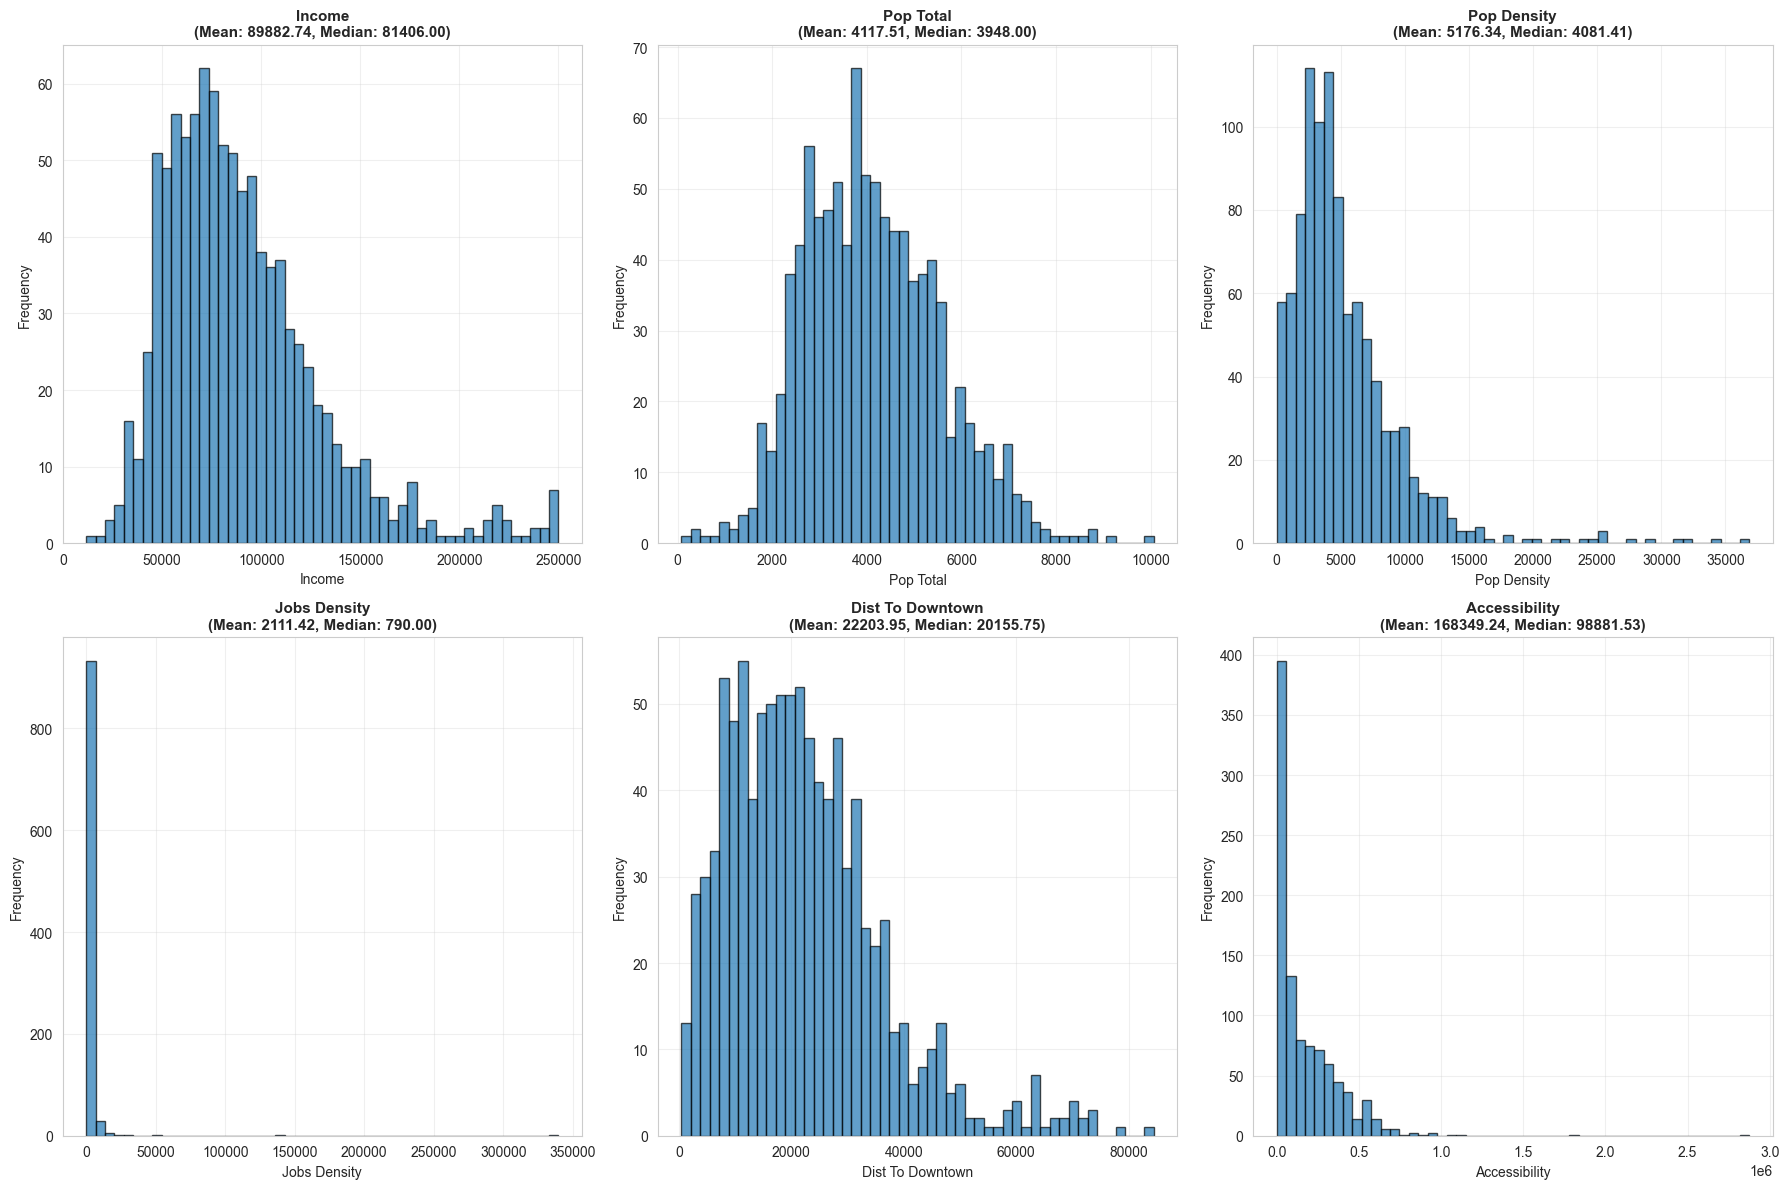

In [5]:
key_features = ['income', 'pop_total', 'pop_density', 'jobs_density', 'dist_to_downtown', 'accessibility']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in features.columns:
        data = features[feat].dropna()
        axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{feat.replace("_", " ").title()}\n(Mean: {data.mean():.2f}, Median: {data.median():.2f})', 
                         fontsize=11, fontweight='bold')
        axes[i].set_xlabel(feat.replace('_', ' ').title())
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(outputs / 'feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved feature distributions plot")
plt.show()


## Step 3: Correlation Analysis


In [6]:
# Correlation matrix: all features vs accessibility
print("Calculating correlation matrix...")

# Calculate Pearson correlation
corr_matrix = features.corr()

access_corr = corr_matrix['accessibility'].sort_values(ascending=False)

print("\n" + "=" * 80)
print("CORRELATIONS WITH ACCESSIBILITY (Pearson)")
print("=" * 80)
for feat, corr in access_corr.items():
    if feat != 'accessibility':
        print(f"  {feat:25s}: {corr:7.3f}")

access_corr.to_csv(outputs / 'accessibility_correlations.csv')
print(f"\n✓ Saved correlations to outputs/accessibility_correlations.csv")


Calculating correlation matrix...

CORRELATIONS WITH ACCESSIBILITY (Pearson)
  pop_density              :   0.362
  jobs_density             :   0.185
  jobs_total               :   0.166
  income_x_jobs            :   0.122
  jobs_density_lag         :   0.015
  pop_density_lag          :   0.006
  jobs_total_lag           :   0.002
  pop_x_jobs               :  -0.023
  income_lag               :  -0.025
  y_coord                  :  -0.032
  pop_total_lag            :  -0.055
  x_coord                  :  -0.198
  income                   :  -0.282
  income_x_pop             :  -0.453
  pop_total                :  -0.466
  dist_to_downtown         :  -0.582

✓ Saved correlations to outputs/accessibility_correlations.csv


✓ Saved correlation heatmap


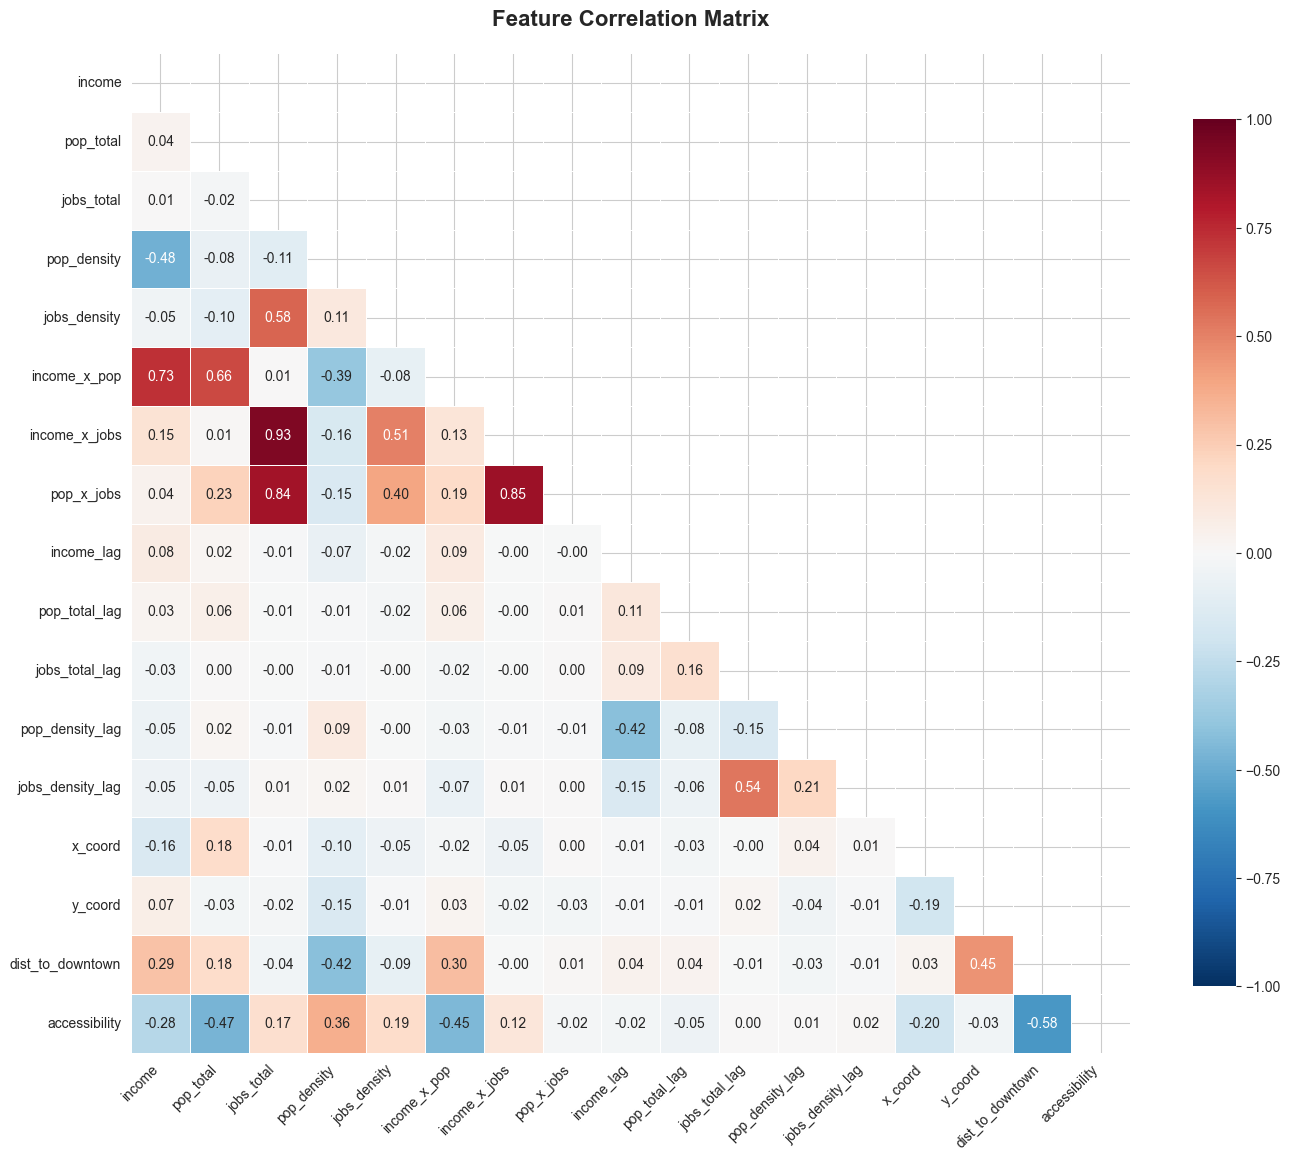

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(outputs / 'correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved correlation heatmap")
plt.show()


✓ Saved top features correlation heatmap


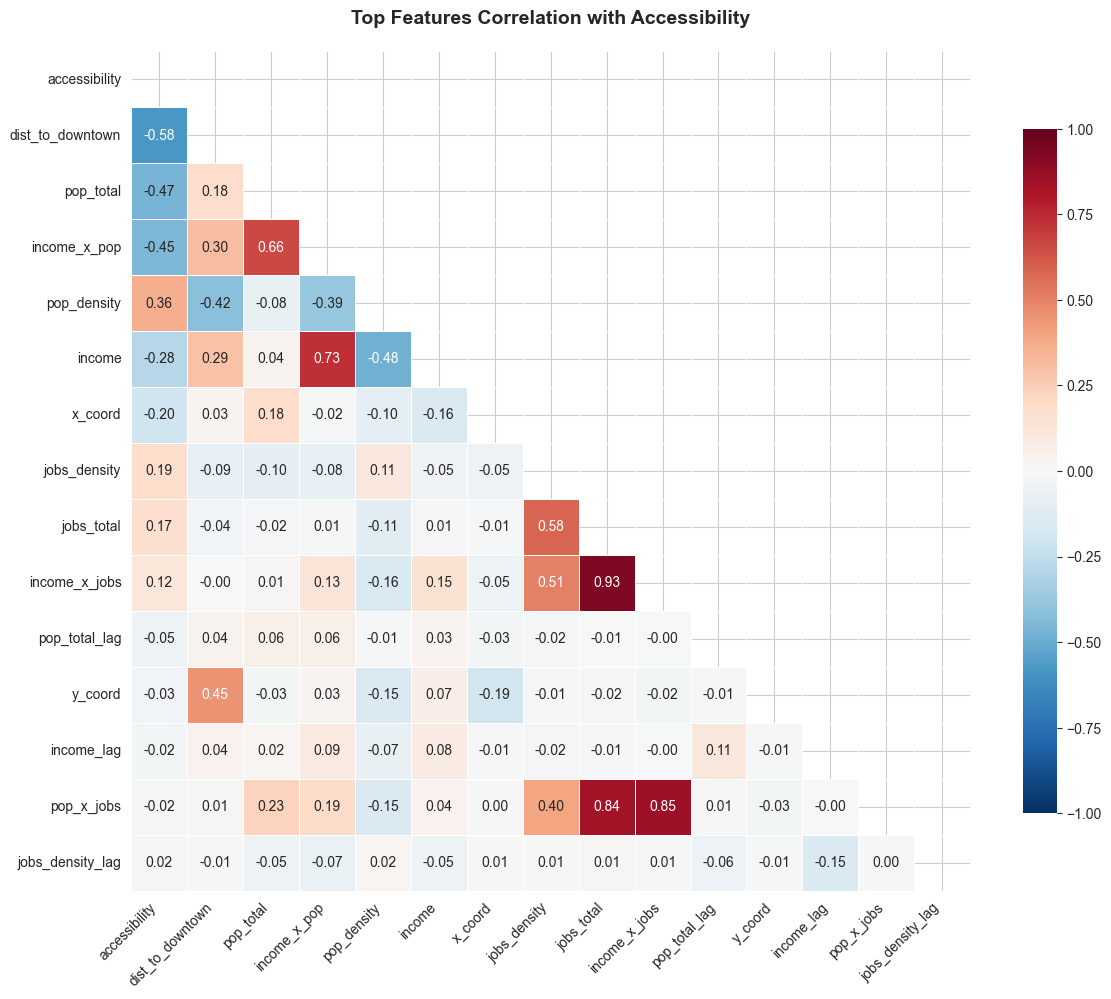

In [8]:
# Focused heatmap: top features vs accessibility
top_features = access_corr.abs().sort_values(ascending=False).head(15).index.tolist()
if 'accessibility' not in top_features:
    top_features.append('accessibility')

corr_subset = corr_matrix.loc[top_features, top_features]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Top Features Correlation with Accessibility', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(outputs / 'top_features_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved top features correlation heatmap")
plt.show()


## Step 4: Feature vs Accessibility Scatter Plots


✓ Saved scatter plots


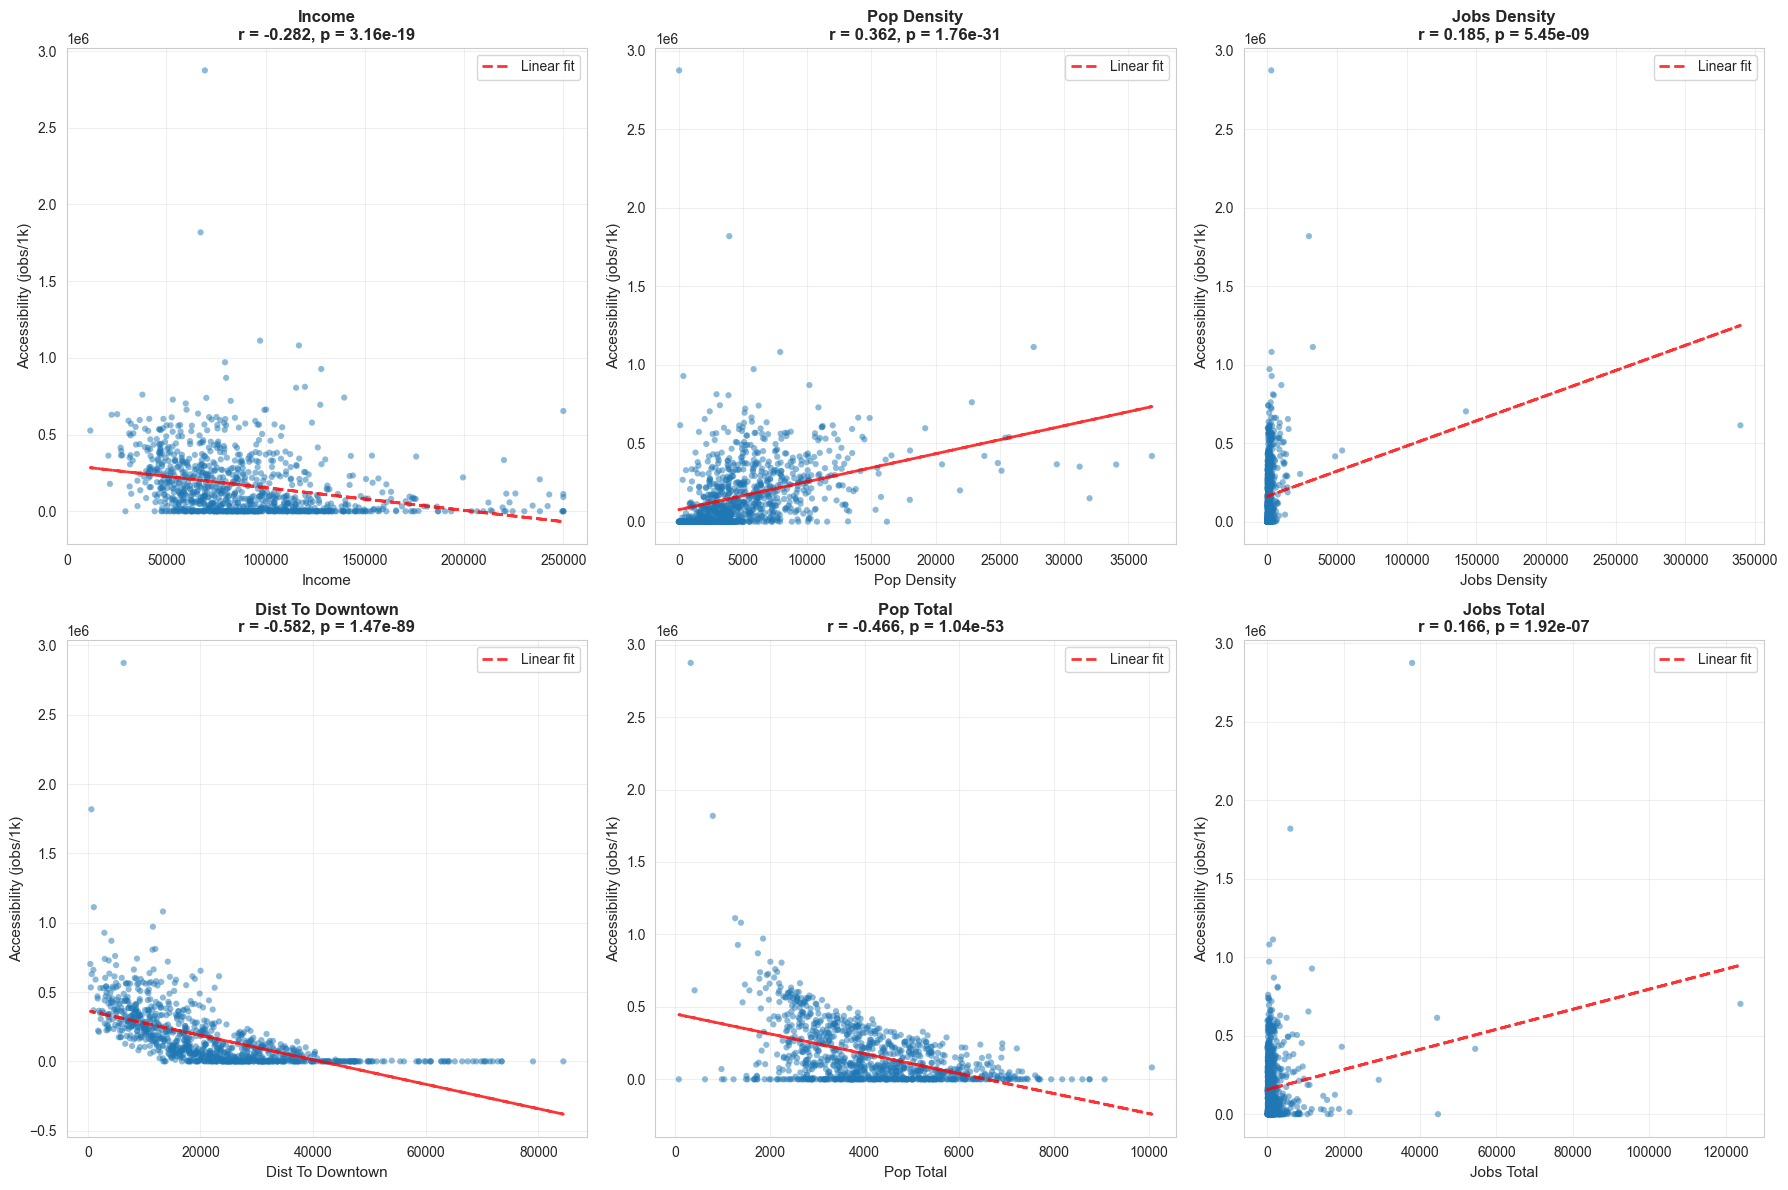

In [9]:
key_features_scatter = ['income', 'pop_density', 'jobs_density', 'dist_to_downtown', 
                       'pop_total', 'jobs_total']

n_features = len(key_features_scatter)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for i, feat in enumerate(key_features_scatter):
    if feat in features.columns:
        x_data = features[feat].values
        y_data = features['accessibility'].values
        
        corr, p_value = pearsonr(x_data, y_data)
        
        axes[i].scatter(x_data, y_data, alpha=0.5, s=20, edgecolors='none')
        
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        axes[i].plot(x_data, p(x_data), "r--", alpha=0.8, linewidth=2, label=f'Linear fit')
        
        axes[i].set_xlabel(feat.replace('_', ' ').title(), fontsize=11)
        axes[i].set_ylabel('Accessibility (jobs/1k)', fontsize=11)
        axes[i].set_title(f'{feat.replace("_", " ").title()}\nr = {corr:.3f}, p = {p_value:.2e}', 
                         fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(outputs / 'feature_vs_accessibility_scatter.png', dpi=300, bbox_inches='tight')
print("✓ Saved scatter plots")
plt.show()


## Step 5: Well-Connected vs Poorly Connected Areas Comparison


In [10]:
access_median = features['accessibility'].median()
access_75th = features['accessibility'].quantile(0.75)
access_25th = features['accessibility'].quantile(0.25)

# Well-connected: top 25% accessibility
well_connected = features['accessibility'] >= access_75th
# Poorly connected: bottom 25% accessibility
poorly_connected = features['accessibility'] <= access_25th

print("=" * 80)
print("WELL-CONNECTED vs POORLY CONNECTED AREAS")
print("=" * 80)
print(f"\nWell-connected (top 25%): {well_connected.sum()} tracts")
print(f"  Accessibility threshold: >= {access_75th:.0f} jobs/1k")
print(f"\nPoorly connected (bottom 25%): {poorly_connected.sum()} tracts")
print(f"  Accessibility threshold: <= {access_25th:.0f} jobs/1k")

comparison = pd.DataFrame({
    'Well_Connected': features[well_connected][feature_cols].mean(),
    'Poorly_Connected': features[poorly_connected][feature_cols].mean(),
    'Difference': features[well_connected][feature_cols].mean() - features[poorly_connected][feature_cols].mean(),
    'Pct_Difference': ((features[well_connected][feature_cols].mean() - features[poorly_connected][feature_cols].mean()) / 
                      features[poorly_connected][feature_cols].mean() * 100)
})

comparison = comparison.sort_values('Pct_Difference', key=abs, ascending=False)
print("\n" + comparison.to_string())

comparison.to_csv(outputs / 'well_vs_poorly_connected_comparison.csv')
print(f"\n✓ Saved comparison to outputs/well_vs_poorly_connected_comparison.csv")


WELL-CONNECTED vs POORLY CONNECTED AREAS

Well-connected (top 25%): 244 tracts
  Accessibility threshold: >= 264800 jobs/1k

Poorly connected (bottom 25%): 244 tracts
  Accessibility threshold: <= 3913 jobs/1k

                  Well_Connected  Poorly_Connected    Difference  Pct_Difference
jobs_density        5.183559e+03      6.534687e+02   4530.090538      693.237523
pop_density         7.895277e+03      2.663411e+03   5231.865483      196.434759
dist_to_downtown    9.633800e+03      3.711938e+04 -27485.574909      -74.046437
income_x_pop        2.109053e+02      4.820702e+02   -271.164911      -56.250087
jobs_total          2.472041e+03      1.637033e+03    835.008197       51.007420
income              7.072153e+04      1.080151e+05 -37293.553279      -34.526245
pop_total           3.056820e+03      4.552910e+03  -1496.090164      -32.860088
income_x_jobs       1.949756e+02      1.635302e+02     31.445371       19.229088
pop_x_jobs          6.258336e-03      7.479823e-03     -0.00

/var/folders/jp/c8jhgklj2l71r2jgjptsxm6m0000gn/T/ipykernel_7680/1542032781.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=['Poorly Connected', 'Well Connected'],
/var/folders/jp/c8jhgklj2l71r2jgjptsxm6m0000gn/T/ipykernel_7680/1542032781.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=['Poorly Connected', 'Well Connected'],
/var/folders/jp/c8jhgklj2l71r2jgjptsxm6m0000gn/T/ipykernel_7680/1542032781.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=['Poorly Connected', 'Well Connecte

✓ Saved comparison box plots


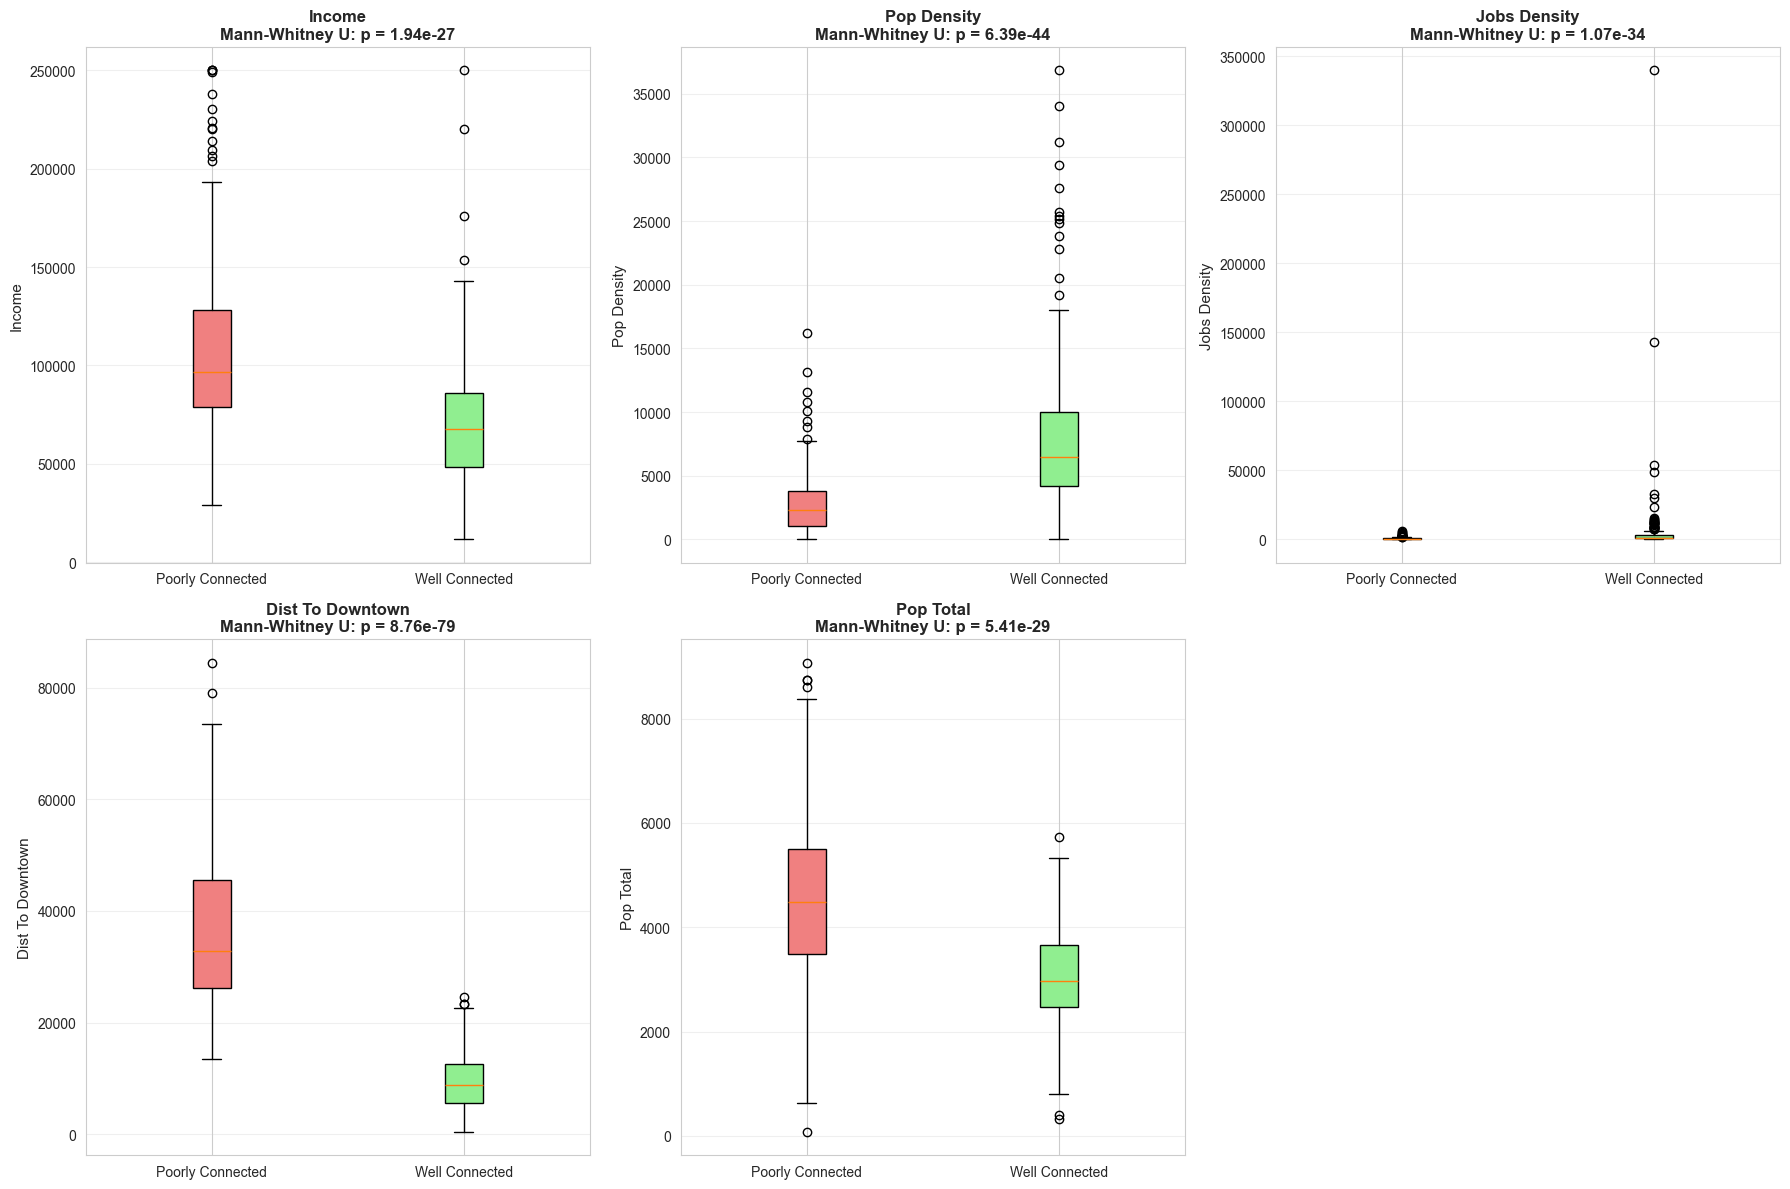

In [11]:
key_features_box = ['income', 'pop_density', 'jobs_density', 'dist_to_downtown', 'pop_total']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(key_features_box):
    if feat in features.columns:
        well_data = features.loc[well_connected, feat]
        poor_data = features.loc[poorly_connected, feat]
        
        stat, p_val = stats.mannwhitneyu(well_data, poor_data, alternative='two-sided')
        
        data_to_plot = [poor_data, well_data]
        bp = axes[i].boxplot(data_to_plot, labels=['Poorly Connected', 'Well Connected'], 
                            patch_artist=True)
        
        colors = ['lightcoral', 'lightgreen']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        axes[i].set_ylabel(feat.replace('_', ' ').title(), fontsize=11)
        axes[i].set_title(f'{feat.replace("_", " ").title()}\nMann-Whitney U: p = {p_val:.2e}', 
                         fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.3, axis='y')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig(outputs / 'well_vs_poorly_connected_boxplots.png', dpi=300, bbox_inches='tight')
print("✓ Saved comparison box plots")
plt.show()


## Step 6: Spatial Patterns in Feature Relationships


✓ Saved connection status map


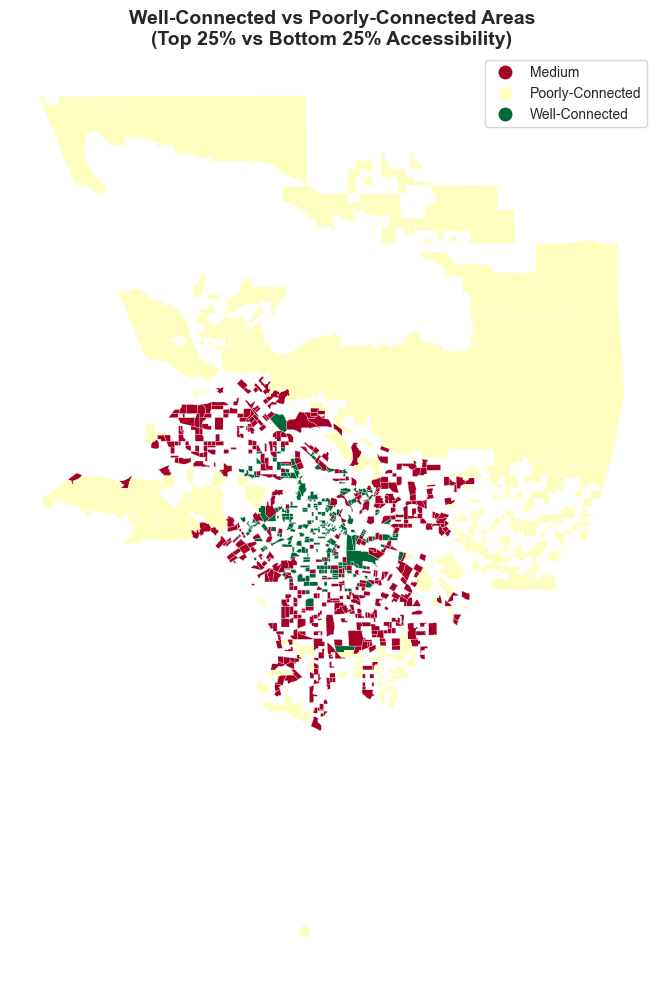

In [12]:
# Map: Well-connected vs poorly connected areas
tracts_proj['connection_status'] = 'Medium'
tracts_proj.loc[well_connected, 'connection_status'] = 'Well-Connected'
tracts_proj.loc[poorly_connected, 'connection_status'] = 'Poorly-Connected'

fig, ax = plt.subplots(figsize=(14, 10))

tracts_proj.to_crs('EPSG:4326').plot(
    column='connection_status',
    categorical=True,
    legend=True,
    cmap='RdYlGn',
    ax=ax,
    edgecolor='white',
    linewidth=0.2
)

ax.set_title('Well-Connected vs Poorly-Connected Areas\n(Top 25% vs Bottom 25% Accessibility)', 
            fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(outputs / 'connection_status_map.png', dpi=300, bbox_inches='tight')
print("✓ Saved connection status map")
plt.show()


✓ Saved key features spatial maps


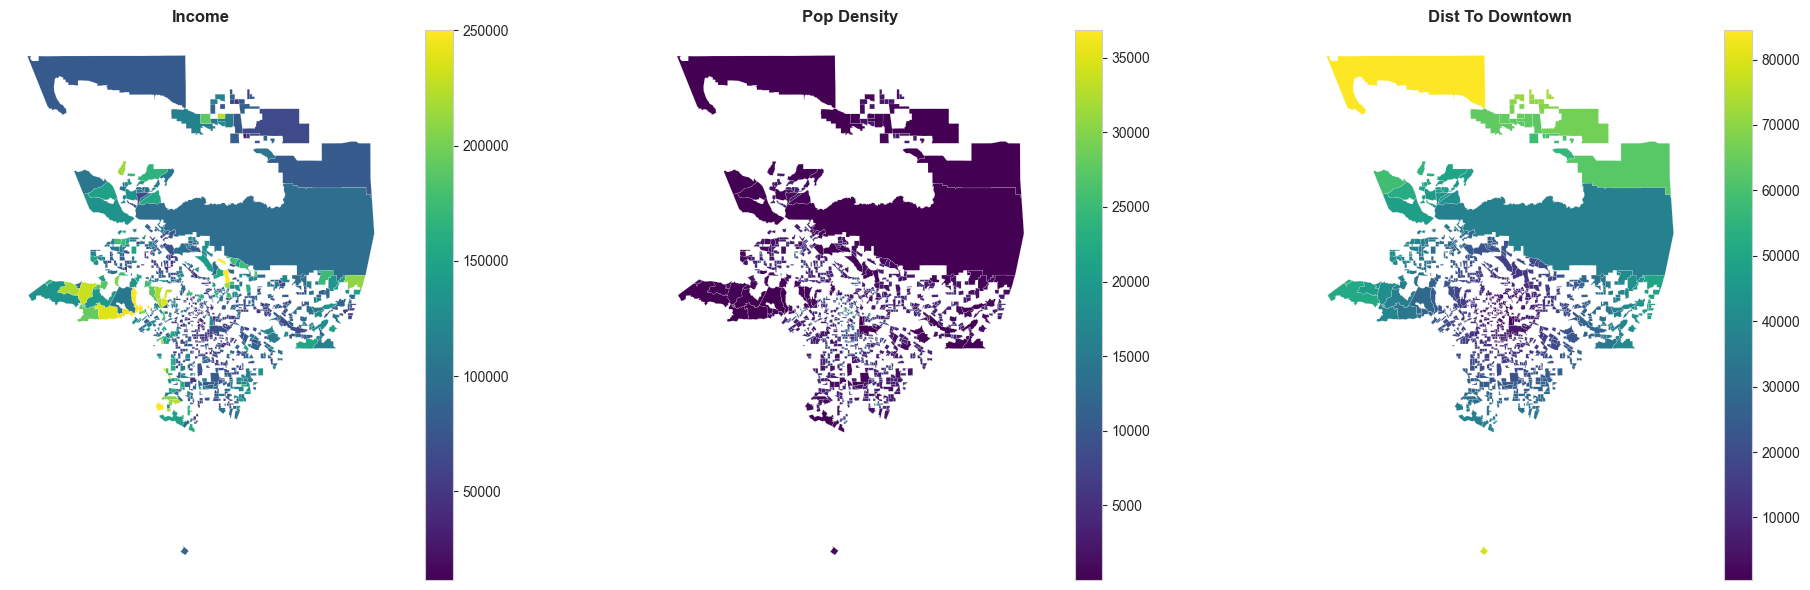

In [13]:
# Maps: Key features colored by accessibility relationship
key_features_map = ['income', 'pop_density', 'dist_to_downtown']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, feat in enumerate(key_features_map):
    if feat in tracts_proj.columns:
        tracts_proj.to_crs('EPSG:4326').plot(
            column=feat,
            cmap='viridis',
            legend=True,
            ax=axes[i],
            edgecolor='white',
            linewidth=0.1
        )
        axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(outputs / 'key_features_spatial_maps.png', dpi=300, bbox_inches='tight')
print("✓ Saved key features spatial maps")
plt.show()


## Step 7: Interaction Effects Analysis


✓ Saved interaction effects plots


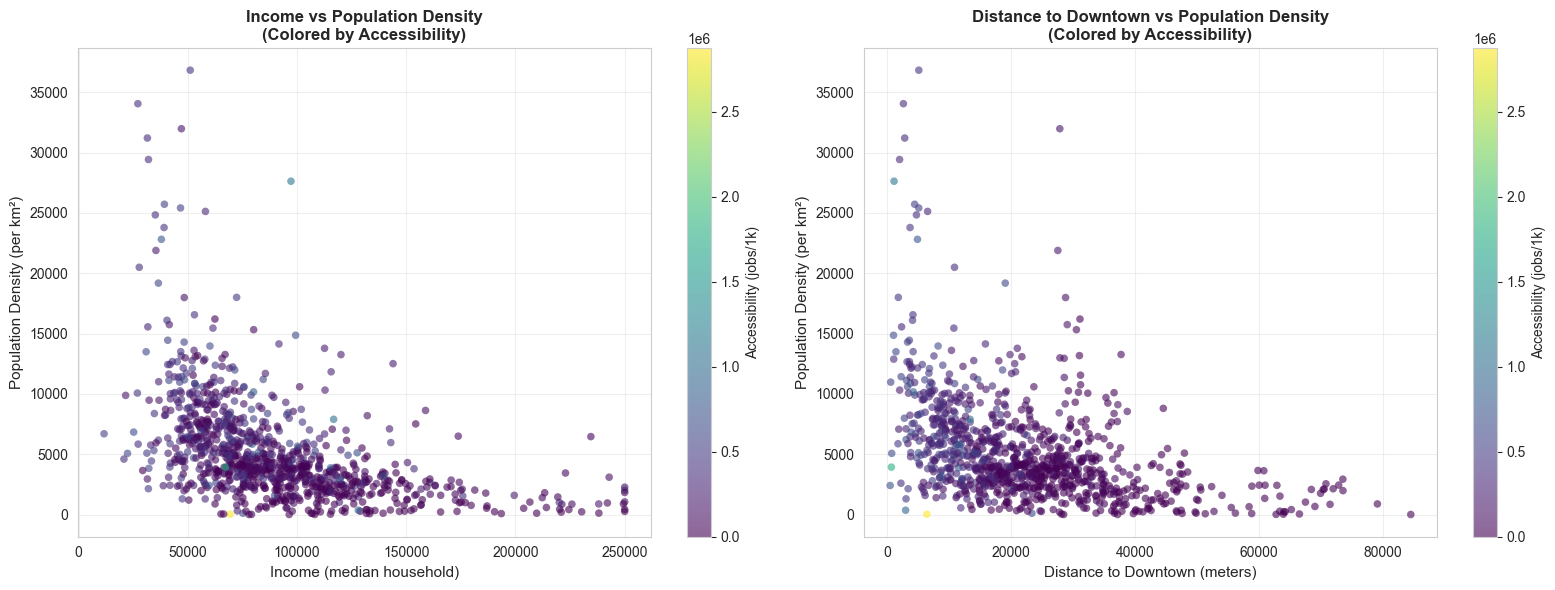

In [14]:
# Income vs Population Density, colored by accessibility
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(features['income'], features['pop_density'], 
                          c=features['accessibility'], cmap='viridis', 
                          s=30, alpha=0.6, edgecolors='none')
axes[0].set_xlabel('Income (median household)', fontsize=11)
axes[0].set_ylabel('Population Density (per km²)', fontsize=11)
axes[0].set_title('Income vs Population Density\n(Colored by Accessibility)', 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Accessibility (jobs/1k)')

scatter2 = axes[1].scatter(features['dist_to_downtown'], features['pop_density'], 
                          c=features['accessibility'], cmap='viridis', 
                          s=30, alpha=0.6, edgecolors='none')
axes[1].set_xlabel('Distance to Downtown (meters)', fontsize=11)
axes[1].set_ylabel('Population Density (per km²)', fontsize=11)
axes[1].set_title('Distance to Downtown vs Population Density\n(Colored by Accessibility)', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Accessibility (jobs/1k)')

plt.tight_layout()
plt.savefig(outputs / 'interaction_effects_scatter.png', dpi=300, bbox_inches='tight')
print("✓ Saved interaction effects plots")
plt.show()


## Step 8: Spatial Lag Analysis (if available)


SPATIAL LAG ANALYSIS

Correlation between base features and their spatial lags:
  income               <-> income_lag          : r = 0.084
  pop_total            <-> pop_total_lag       : r = 0.062
  jobs_total           <-> jobs_total_lag      : r = -0.000
  pop_density          <-> pop_density_lag     : r = 0.093
  jobs_density         <-> jobs_density_lag    : r = 0.006

Correlation of spatial lags with accessibility:
  income_lag               : r = -0.025
  pop_total_lag            : r = -0.055
  jobs_total_lag           : r = 0.002
  pop_density_lag          : r = 0.006
  jobs_density_lag         : r = 0.015

✓ Saved spatial lag analysis plots


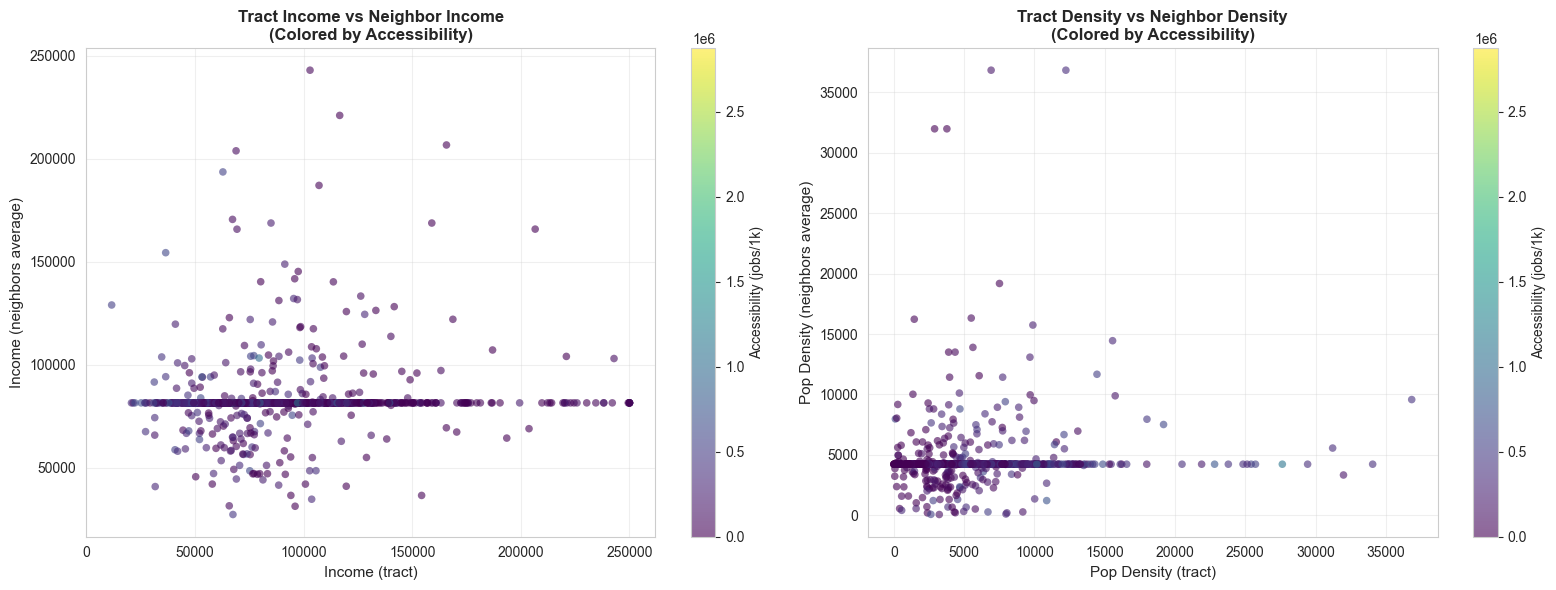

In [15]:
lag_features = [c for c in features.columns if '_lag' in c]

if len(lag_features) > 0:
    print("=" * 80)
    print("SPATIAL LAG ANALYSIS")
    print("=" * 80)
    
    print("\nCorrelation between base features and their spatial lags:")
    for lag_feat in lag_features:
        base_feat = lag_feat.replace('_lag', '')
        if base_feat in features.columns:
            corr = features[base_feat].corr(features[lag_feat])
            print(f"  {base_feat:20s} <-> {lag_feat:20s}: r = {corr:.3f}")
    
    print("\nCorrelation of spatial lags with accessibility:")
    for lag_feat in lag_features:
        corr = features[lag_feat].corr(features['accessibility'])
        print(f"  {lag_feat:25s}: r = {corr:.3f}")
    
    if 'income' in features.columns and 'income_lag' in features.columns:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Income vs Income Lag
        scatter1 = axes[0].scatter(features['income'], features['income_lag'], 
                                  c=features['accessibility'], cmap='viridis', 
                                  s=30, alpha=0.6, edgecolors='none')
        axes[0].set_xlabel('Income (tract)', fontsize=11)
        axes[0].set_ylabel('Income (neighbors average)', fontsize=11)
        axes[0].set_title('Tract Income vs Neighbor Income\n(Colored by Accessibility)', 
                         fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=axes[0], label='Accessibility (jobs/1k)')
        
        # Pop Density vs Pop Density Lag
        if 'pop_density' in features.columns and 'pop_density_lag' in features.columns:
            scatter2 = axes[1].scatter(features['pop_density'], features['pop_density_lag'], 
                                      c=features['accessibility'], cmap='viridis', 
                                      s=30, alpha=0.6, edgecolors='none')
            axes[1].set_xlabel('Pop Density (tract)', fontsize=11)
            axes[1].set_ylabel('Pop Density (neighbors average)', fontsize=11)
            axes[1].set_title('Tract Density vs Neighbor Density\n(Colored by Accessibility)', 
                             fontsize=12, fontweight='bold')
            axes[1].grid(True, alpha=0.3)
            plt.colorbar(scatter2, ax=axes[1], label='Accessibility (jobs/1k)')
        
        plt.tight_layout()
        plt.savefig(outputs / 'spatial_lag_analysis.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved spatial lag analysis plots")
        plt.show()
else:
    print("⚠ No spatial lag features available. Skipping spatial lag analysis.")


## Step 9: Key Insights and Recommendations


In [16]:
print("=" * 80)
print("KEY INSIGHTS FOR TRANSIT PLANNING")
print("=" * 80)

print("\n1. TOP FEATURES ASSOCIATED WITH ACCESSIBILITY:")
top_5_corr = access_corr.abs().sort_values(ascending=False).head(6)
for i, (feat, corr) in enumerate(top_5_corr.items(), 1):
    if feat != 'accessibility':
        direction = "positive" if access_corr[feat] > 0 else "negative"
        print(f"   {i}. {feat:25s}: r = {corr:.3f} ({direction} association)")

print("\n2. WELL-CONNECTED vs POORLY-CONNECTED DIFFERENCES:")
top_3_diff = comparison['Pct_Difference'].abs().sort_values(ascending=False).head(3)
for feat in top_3_diff.index:
    pct_diff = comparison.loc[feat, 'Pct_Difference']
    well_val = comparison.loc[feat, 'Well_Connected']
    poor_val = comparison.loc[feat, 'Poorly_Connected']
    print(f"   • {feat:25s}: {pct_diff:+.1f}% difference")
    print(f"     Well-connected: {well_val:.2f}, Poorly-connected: {poor_val:.2f}")

print("\n3. SPATIAL PATTERNS:")
if 'dist_to_downtown' in features.columns:
    well_dist = features.loc[well_connected, 'dist_to_downtown'].mean()
    poor_dist = features.loc[poorly_connected, 'dist_to_downtown'].mean()
    print(f"   • Well-connected areas are {((poor_dist - well_dist) / poor_dist * 100):.1f}% closer to downtown")
    print(f"     Well-connected avg distance: {well_dist/1000:.1f} km")
    print(f"     Poorly-connected avg distance: {poor_dist/1000:.1f} km")

print("\n4. RECOMMENDATIONS FOR TRANSIT IMPROVEMENTS:")
print("   • Focus on areas with high population density but low accessibility")
print("   • Prioritize transit expansion to areas far from downtown with high demand")
print("   • Consider demographic factors: income, population, job density")
print("   • Spatial context matters: neighbor characteristics influence accessibility")

print("\n" + "=" * 80)


KEY INSIGHTS FOR TRANSIT PLANNING

1. TOP FEATURES ASSOCIATED WITH ACCESSIBILITY:
   2. dist_to_downtown         : r = 0.582 (negative association)
   3. pop_total                : r = 0.466 (negative association)
   4. income_x_pop             : r = 0.453 (negative association)
   5. pop_density              : r = 0.362 (positive association)
   6. income                   : r = 0.282 (negative association)

2. WELL-CONNECTED vs POORLY-CONNECTED DIFFERENCES:
   • jobs_density             : +693.2% difference
     Well-connected: 5183.56, Poorly-connected: 653.47
   • pop_density              : +196.4% difference
     Well-connected: 7895.28, Poorly-connected: 2663.41
   • dist_to_downtown         : -74.0% difference
     Well-connected: 9633.80, Poorly-connected: 37119.38

3. SPATIAL PATTERNS:
   • Well-connected areas are 74.0% closer to downtown
     Well-connected avg distance: 9.6 km
     Poorly-connected avg distance: 37.1 km

4. RECOMMENDATIONS FOR TRANSIT IMPROVEMENTS:
   • Foc